In [45]:
import pandas as pd

df = pd.read_csv('../data/e-commerce.csv', encoding='latin-1')


In [46]:
print(df.shape)


(541909, 8)


#Answer 541909 rows and 8 columns



In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


For datatype there the columns Customer ID and InvoiceDate should in str and datetime respectively.
For I have spot out some missing infos let me spot out.

In [48]:
df.isna().sum() # Missing records 
#1454 records in description are missing
#135080 of customer ID are missing


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [49]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [50]:
df['Sales'] = df['Quantity']* df['UnitPrice']


In [51]:
result = df.groupby('Country')['Sales'].sum()

In [52]:
print(result.sort_values(ascending=False).head(10))

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Sales, dtype: float64


In [53]:
# 假設你有兩個 DataFrame
orders = df.groupby('CustomerID')['Sales'].sum().reset_index()
orders
#what is reset_index() is doing? turn the orders from series into dataframe
# what is a series 
#series does not has attribute
#I also find that the print from jupyternotebook of both series and dataframe are quite different

,CustomerID,Sales
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4367,18280.0,180.60
4368,18281.0,80.82
4369,18282.0,176.60
4370,18283.0,2094.88


In [54]:
country = df[['CustomerID', 'Country']].drop_duplicates()
country.head()
#.drop_duplicates removes any duplicates on the index
#index msut be unique for any database
# why when selecting two columns another [] must be used or else keyerror will be spot out?
#python does not have unique check

,CustomerID,Country
0,17850.0,United Kingdom
9,13047.0,United Kingdom
26,12583.0,France
46,13748.0,United Kingdom
65,15100.0,United Kingdom


In [55]:
# 合併兩個 DataFrame
result = orders.merge(country)
print(result.head(5))
#it becomes a series
#python can auto detect the common indexes?


   CustomerID    Sales         Country
0     12346.0     0.00  United Kingdom
1     12347.0  4310.00         Iceland
2     12348.0  1797.24         Finland
3     12349.0  1757.55           Italy
4     12350.0   334.40          Norway


In [56]:
result2=orders.merge(country, on='CustomerID')
result2.head()
# it becomes a dataframe
#it is merge can recognize the join index I forget what is the name of it

,CustomerID,Sales,Country
0,12346.0,0.00,United Kingdom
1,12347.0,4310.00,Iceland
2,12348.0,1797.24,Finland
3,12349.0,1757.55,Italy
4,12350.0,334.40,Norway


In [57]:
#pandas missing and cleaning syntax is not trained yet

In [58]:
result['Country'].nunique()

37

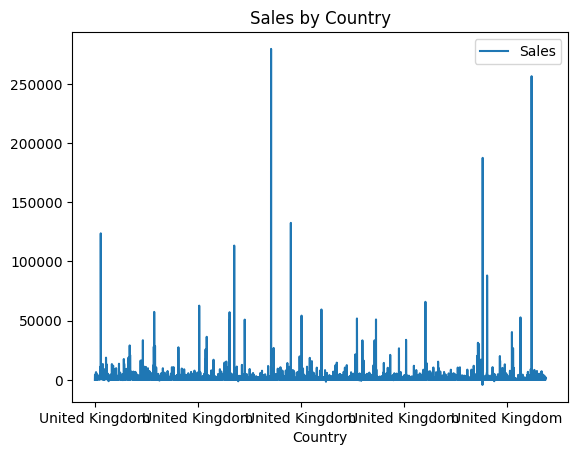

In [59]:
import matplotlib.pyplot as plt

# 用你剛做的 result
result.plot(x='Country', y='Sales', kind='line')
plt.title('Sales by Country')
plt.savefig('chart.png')
plt.show()

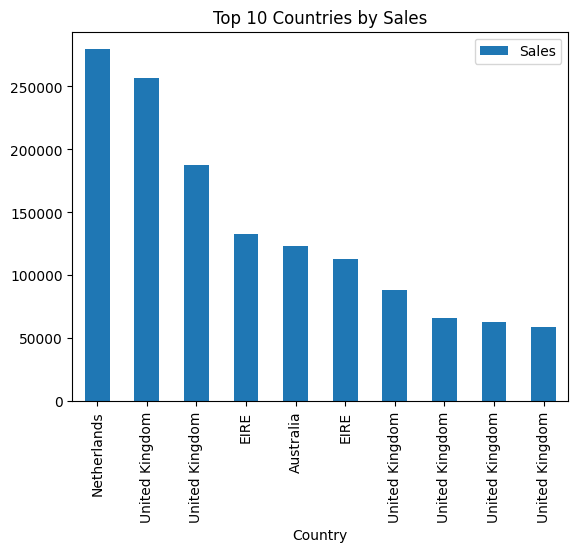

In [60]:
# 只取 Top 10
top10 = result.sort_values('Sales', ascending=False).head(10)
top10.plot(x='Country', y='Sales', kind='bar')
plt.title('Top 10 Countries by Sales')
plt.show()

In [62]:
df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head()
#The total number of UK customers is far beyond other european countries

Country
United Kingdom    3950
Germany             95
France              87
Spain               31
Belgium             25
Name: CustomerID, dtype: int64

In [63]:
result.head()

,CustomerID,Sales,Country
0,12346.0,0.00,United Kingdom
1,12347.0,4310.00,Iceland
2,12348.0,1797.24,Finland
3,12349.0,1757.55,Italy
4,12350.0,334.40,Norway


In [ ]:
no_cus=df.groupby('Country')['CustomerID'].nunique().reset_index()
no_cus=no_cus.rename(columns={'CustomerID':'No_of_Customers'})
no_cus_series = no_cus.set_index('Country')['No_of_Customers']

no_cus_series

,Country,No_of_Customers
0,Australia,9
1,Austria,11
2,Bahrain,2
3,Belgium,25
4,Brazil,1


In [ ]:
total_sales_of_each_country=result.groupby('Country')['Sales'].sum().reset_index()
total_sales_of_each_country=total_sales_of_each_country.rename({'Sales':'Total Revenue'})

#result['CustomerID'].map(no_cus)

In [88]:
total_sales_of_each_country=total_sales_of_each_country.rename({'Sales':'Total Revenue'}).reset_index()


In [89]:
total_sales_of_each_country['Spending_per_Capita']=total_sales_of_each_country['Sales']/total_sales_of_each_country['Country'].map(no_cus_series)

In [93]:
total_sales_of_each_country.sort_values(by='Spending_per_Capita',ascending=False).head()

,Country,Sales,Spending_per_Capita
10,EIRE,250285.22,83428.406667
23,Netherlands,284661.54,31629.060000
0,Australia,138467.41,15385.267778
29,Singapore,9120.39,9120.390000
31,Sweden,36595.91,4574.488750


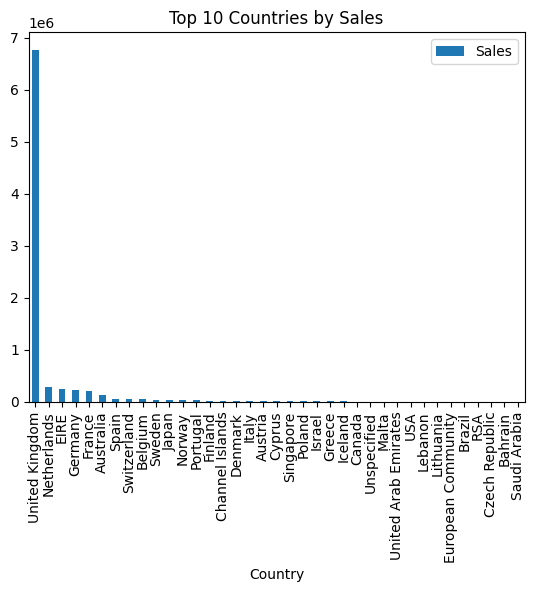

In [94]:
# 只取 Top 10
top10 = result.groupby('Country')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
top10.head(10)
top10.plot(x='Country', y='Sales', kind='bar')
plt.title('Top 10 Countries by Sales')
plt.show()

In [ ]:
total_sales_of_each_country.head(10).plot(x='Country', y='Sales')